# Feature Validation and Preprocessing

This notebook validates the customer-level feature table and prepares a clean feature matrix for K-Means clustering.

The previous notebook created one row per customer. This notebook focuses on feature selection, missing value handling, skew reduction, scaling, and saving model-ready data.

K-Means is not trained in this notebook. Clustering experiments will be handled after the feature matrix is ready.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", "{:,.4f}".format)

sns.set_theme(style="whitegrid", context="notebook")

In [2]:
project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

processed_data_dir = project_root / "data" / "processed"
figures_dir = project_root / "reports" / "figures"

processed_data_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

base_features_path = processed_data_dir / "customer_features_base.csv"


def relative_project_path(path):
    return Path(path).resolve().relative_to(project_root).as_posix()


FIGURE_SAVE_KWARGS = {
    "dpi": 150,
    "bbox_inches": "tight",
    "metadata": {"Date": None},
}


print("Project root: repository root resolved")
print("Processed data directory:", relative_project_path(processed_data_dir))
print("Processed data directory exists:", processed_data_dir.exists())
print("Figures directory:", relative_project_path(figures_dir))
print("Figures directory exists:", figures_dir.exists())
print("Base feature file:", relative_project_path(base_features_path))
print("Base feature file exists:", base_features_path.exists())

Project root: repository root resolved
Processed data directory: data/processed
Processed data directory exists: True
Figures directory: reports/figures
Figures directory exists: True
Base feature file: data/processed/customer_features_base.csv
Base feature file exists: True


## Load Customer-Level Feature Table

The input file is the customer-level analytical dataset created from delivered Olist orders. Each row represents one `customer_unique_id`.

In [3]:
customer_features = pd.read_csv(base_features_path)

print("Shape:", customer_features.shape)
print("Unique customers:", customer_features["customer_unique_id"].nunique())
print("Duplicate customer_unique_id:", customer_features["customer_unique_id"].duplicated().sum())

display(customer_features.head())

Shape: (93350, 23)
Unique customers: 93350
Duplicate customer_unique_id: 0


,customer_unique_id,recency_days,customer_lifetime_days,order_count,total_payment_value,avg_payment_value,avg_payment_installments,avg_payment_method_count,total_items,avg_items_per_order,total_product_count,avg_product_count_per_order,max_category_count_per_order,total_item_price,total_freight_value,avg_freight_value,freight_to_payment_ratio,avg_review_score,review_count,avg_delivery_days,late_delivery_rate,first_purchase_date,last_purchase_date
0,0000366f3b9a7992bf8c76cfdf3221e2,112.1696,0.0000,1,141.9000,141.9000,8.0000,1.0000,1,1.0000,1,1.0000,1,129.9000,12.0000,12.0000,0.0846,5.0000,1.0000,6.4112,0.0000,2018-05-10 10:56:27,2018-05-10 10:56:27
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115.1591,0.0000,1,27.1900,27.1900,1.0000,1.0000,1,1.0000,1,1.0000,1,18.9000,8.2900,8.2900,0.3049,4.0000,1.0000,3.2856,0.0000,2018-05-07 11:11:27,2018-05-07 11:11:27
2,0000f46a3911fa3c0805444483337064,537.7469,0.0000,1,86.2200,86.2200,8.0000,1.0000,1,1.0000,1,1.0000,1,69.0000,17.2200,17.2200,0.1997,3.0000,1.0000,25.7318,0.0000,2017-03-10 21:05:03,2017-03-10 21:05:03
3,0000f6ccb0745a6a4b88665a16c9f078,321.7715,0.0000,1,43.6200,43.6200,4.0000,1.0000,1,1.0000,1,1.0000,1,25.9900,17.6300,17.6300,0.4042,4.0000,1.0000,20.0371,0.0000,2017-10-12 20:29:41,2017-10-12 20:29:41
4,0004aac84e0df4da2b147fca70cf8255,288.8020,0.0000,1,196.8900,196.8900,6.0000,1.0000,1,1.0000,1,1.0000,1,180.0000,16.8900,16.8900,0.0858,5.0000,1.0000,13.1411,0.0000,2017-11-14 19:45:42,2017-11-14 19:45:42


In [4]:
required_columns = [
    "customer_unique_id",
    "recency_days",
    "order_count",
    "total_payment_value",
    "avg_payment_installments",
    "total_product_count",
    "freight_to_payment_ratio",
    "avg_review_score",
    "avg_delivery_days",
    "late_delivery_rate",
]

missing_required_columns = [column for column in required_columns if column not in customer_features.columns]

if missing_required_columns:
    raise ValueError(f"Missing required columns: {missing_required_columns}")

print("All required columns are available.")

All required columns are available.


## Feature Selection

The selected features represent shopping behavior, payment behavior, satisfaction, and delivery experience. Raw identifiers and date columns are not used as model features because K-Means needs numeric behavioral variables, not IDs.

In [5]:
feature_selection_notes = pd.DataFrame(
    [
        {
            "feature": "recency_days",
            "behavior_group": "Recency",
            "reason": "Measures how recently the customer purchased.",
        },
        {
            "feature": "order_count",
            "behavior_group": "Frequency",
            "reason": "Measures how often the customer purchased.",
        },
        {
            "feature": "total_payment_value",
            "behavior_group": "Monetary",
            "reason": "Measures total completed purchase value.",
        },
        {
            "feature": "avg_payment_installments",
            "behavior_group": "Payment behavior",
            "reason": "Captures installment usage behavior.",
        },
        {
            "feature": "total_product_count",
            "behavior_group": "Product behavior",
            "reason": "Captures product variety across completed purchases.",
        },
        {
            "feature": "freight_to_payment_ratio",
            "behavior_group": "Freight behavior",
            "reason": "Measures shipping cost burden relative to payment value.",
        },
        {
            "feature": "avg_review_score",
            "behavior_group": "Satisfaction",
            "reason": "Captures average customer review score when available.",
        },
        {
            "feature": "avg_delivery_days",
            "behavior_group": "Delivery experience",
            "reason": "Measures typical delivery duration.",
        },
        {
            "feature": "late_delivery_rate",
            "behavior_group": "Delivery experience",
            "reason": "Measures how often the customer's orders were delivered late.",
        },
        {
            "feature": "has_review_score",
            "behavior_group": "Satisfaction signal",
            "reason": "Preserves whether the customer had review information before imputation.",
        },
    ]
)

display(feature_selection_notes)

,feature,behavior_group,reason
0,recency_days,Recency,Measures how recently the customer purchased.
1,order_count,Frequency,Measures how often the customer purchased.
2,total_payment_value,Monetary,Measures total completed purchase value.
3,avg_payment_installments,Payment behavior,Captures installment usage behavior.
4,total_product_count,Product behavior,Captures product variety across completed purc...
5,freight_to_payment_ratio,Freight behavior,Measures shipping cost burden relative to paym...
6,avg_review_score,Satisfaction,Captures average customer review score when av...
7,avg_delivery_days,Delivery experience,Measures typical delivery duration.
8,late_delivery_rate,Delivery experience,Measures how often the customer's orders were ...
9,has_review_score,Satisfaction signal,Preserves whether the customer had review info...


## Missing Value Check

Missing values must be handled before K-Means. The most important missing value in this dataset is `avg_review_score`, because many customers do not leave reviews. Instead of deleting those customers, the notebook keeps them and creates a `has_review_score` indicator.

In [6]:
selected_features = [
    "recency_days",
    "order_count",
    "total_payment_value",
    "avg_payment_installments",
    "total_product_count",
    "freight_to_payment_ratio",
    "avg_review_score",
    "avg_delivery_days",
    "late_delivery_rate",
]

missing_summary = (
    customer_features[selected_features]
    .isna()
    .sum()
    .rename("missing_count")
    .reset_index()
    .rename(columns={"index": "feature"})
)

missing_summary["missing_percentage"] = (
    missing_summary["missing_count"] / len(customer_features) * 100
)

display(missing_summary.sort_values("missing_count", ascending=False).reset_index(drop=True))

,feature,missing_count,missing_percentage
0,avg_review_score,603,0.6460
1,freight_to_payment_ratio,1,0.0011
2,avg_payment_installments,1,0.0011
3,recency_days,0,0.0000
4,order_count,0,0.0000
5,total_product_count,0,0.0000
6,total_payment_value,0,0.0000
7,avg_delivery_days,0,0.0000
8,late_delivery_rate,0,0.0000


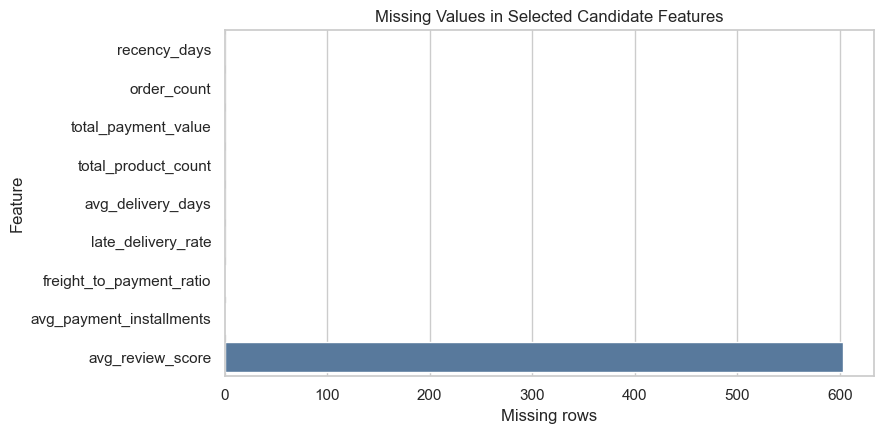

In [7]:
plt.figure(figsize=(9, 4.5))
sns.barplot(
    data=missing_summary.sort_values("missing_count", ascending=True),
    x="missing_count",
    y="feature",
    color="#4C78A8",
)
plt.title("Missing Values in Selected Candidate Features")
plt.xlabel("Missing rows")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(figures_dir / "missing_values_selected_features.png", **FIGURE_SAVE_KWARGS)
plt.show()

## Missing Value Handling

The notebook uses median imputation for selected numeric features. Median is chosen because it is more robust than mean when the distribution is skewed.

For review score, the notebook creates `has_review_score` before imputation. This keeps the information that a customer did or did not have review data.

In [8]:
model_data = customer_features[["customer_unique_id"] + selected_features].copy()

model_data["has_review_score"] = model_data["avg_review_score"].notna().astype(int)

impute_columns = [
    "avg_payment_installments",
    "freight_to_payment_ratio",
    "avg_review_score",
]

impute_values = model_data[impute_columns].median(numeric_only=True)
model_data[impute_columns] = model_data[impute_columns].fillna(impute_values)

imputation_summary = pd.DataFrame(
    {
        "feature": impute_values.index,
        "imputed_value": impute_values.values,
    }
)

print("Missing values after imputation:", model_data.isna().sum().sum())
display(imputation_summary)

Missing values after imputation: 0


,feature,imputed_value
0,avg_payment_installments,2.0000
1,freight_to_payment_ratio,0.1832
2,avg_review_score,5.0000


In [9]:
range_checks = pd.DataFrame(
    [
        {
            "check": "recency_days_non_negative",
            "passed": bool((model_data["recency_days"] >= 0).all()),
        },
        {
            "check": "order_count_at_least_one",
            "passed": bool((model_data["order_count"] >= 1).all()),
        },
        {
            "check": "total_payment_value_non_negative",
            "passed": bool((model_data["total_payment_value"] >= 0).all()),
        },
        {
            "check": "avg_review_score_between_1_and_5",
            "passed": bool(model_data["avg_review_score"].between(1, 5).all()),
        },
        {
            "check": "late_delivery_rate_between_0_and_1",
            "passed": bool(model_data["late_delivery_rate"].between(0, 1).all()),
        },
    ]
)

display(range_checks)

if not range_checks["passed"].all():
    raise ValueError("At least one feature range check failed.")

,check,passed
0,recency_days_non_negative,True
1,order_count_at_least_one,True
2,total_payment_value_non_negative,True
3,avg_review_score_between_1_and_5,True
4,late_delivery_rate_between_0_and_1,True


## Skewness Check

Many customer behavior features are naturally skewed. For example, most customers buy once, while a small number of customers buy more often or spend much more. Log transformation helps reduce extreme scale differences before K-Means.

In [10]:
skewness_before = (
    model_data.drop(columns=["customer_unique_id"])
    .skew(numeric_only=True)
    .sort_values(ascending=False)
    .rename("skewness_before")
    .reset_index()
    .rename(columns={"index": "feature"})
)

display(skewness_before)

,feature,skewness_before
0,order_count,11.0947
1,total_payment_value,9.2107
2,total_product_count,7.3763
3,avg_delivery_days,3.8873
4,late_delivery_rate,3.0593
5,avg_payment_installments,1.6126
6,freight_to_payment_ratio,1.0667
7,recency_days,0.4474
8,avg_review_score,-1.4877
9,has_review_score,-12.3216


In [11]:
log_transform_columns = [
    "recency_days",
    "order_count",
    "total_payment_value",
    "avg_payment_installments",
    "total_product_count",
    "freight_to_payment_ratio",
    "avg_delivery_days",
]

transformed_features = model_data[["customer_unique_id"]].copy()

for column in log_transform_columns:
    transformed_features[f"log_{column}"] = np.log1p(model_data[column])

unchanged_columns = [
    "avg_review_score",
    "late_delivery_rate",
    "has_review_score",
]

for column in unchanged_columns:
    transformed_features[column] = model_data[column]

print("Transformed feature shape:", transformed_features.shape)
display(transformed_features.head())

Transformed feature shape: (93350, 11)


,customer_unique_id,log_recency_days,log_order_count,log_total_payment_value,log_avg_payment_installments,log_total_product_count,log_freight_to_payment_ratio,log_avg_delivery_days,avg_review_score,late_delivery_rate,has_review_score
0,0000366f3b9a7992bf8c76cfdf3221e2,4.7289,0.6931,4.9621,2.1972,0.6931,0.0812,2.0030,5.0000,0.0000,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,4.7550,0.6931,3.3390,0.6931,0.6931,0.2661,1.4553,4.0000,0.0000,1
2,0000f46a3911fa3c0805444483337064,6.2892,0.6931,4.4684,2.1972,0.6931,0.1821,3.2859,3.0000,0.0000,1
3,0000f6ccb0745a6a4b88665a16c9f078,5.7769,0.6931,3.7982,1.6094,0.6931,0.3394,3.0463,4.0000,0.0000,1
4,0004aac84e0df4da2b147fca70cf8255,5.6692,0.6931,5.2877,1.9459,0.6931,0.0823,2.6491,5.0000,0.0000,1


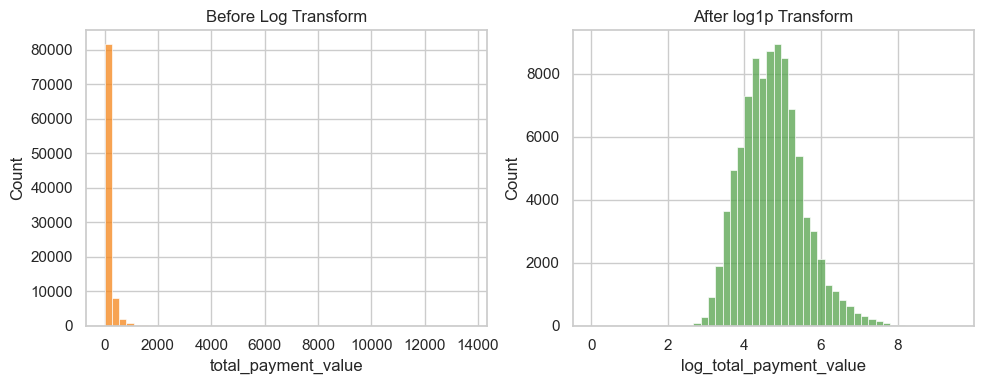

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.histplot(model_data["total_payment_value"], bins=50, ax=axes[0], color="#F58518")
axes[0].set_title("Before Log Transform")
axes[0].set_xlabel("total_payment_value")

sns.histplot(transformed_features["log_total_payment_value"], bins=50, ax=axes[1], color="#54A24B")
axes[1].set_title("After log1p Transform")
axes[1].set_xlabel("log_total_payment_value")

plt.tight_layout()
plt.savefig(figures_dir / "payment_value_log_transform.png", **FIGURE_SAVE_KWARGS)
plt.show()

In [13]:
model_feature_columns = [column for column in transformed_features.columns if column != "customer_unique_id"]

skewness_after = (
    transformed_features[model_feature_columns]
    .skew(numeric_only=True)
    .sort_values(ascending=False)
    .rename("skewness_after")
    .reset_index()
    .rename(columns={"index": "feature"})
)

display(skewness_after)

,feature,skewness_after
0,log_order_count,6.5218
1,log_total_product_count,4.6844
2,late_delivery_rate,3.0593
3,log_avg_payment_installments,0.8132
4,log_freight_to_payment_ratio,0.7842
5,log_total_payment_value,0.5291
6,log_avg_delivery_days,0.0374
7,log_recency_days,-1.1975
8,avg_review_score,-1.4877
9,has_review_score,-12.3216


## Correlation Check

Correlation is checked to understand whether some features carry very similar information. This notebook does not automatically remove features only because they are correlated. The final decision also depends on business interpretability and clustering results in the next notebook.

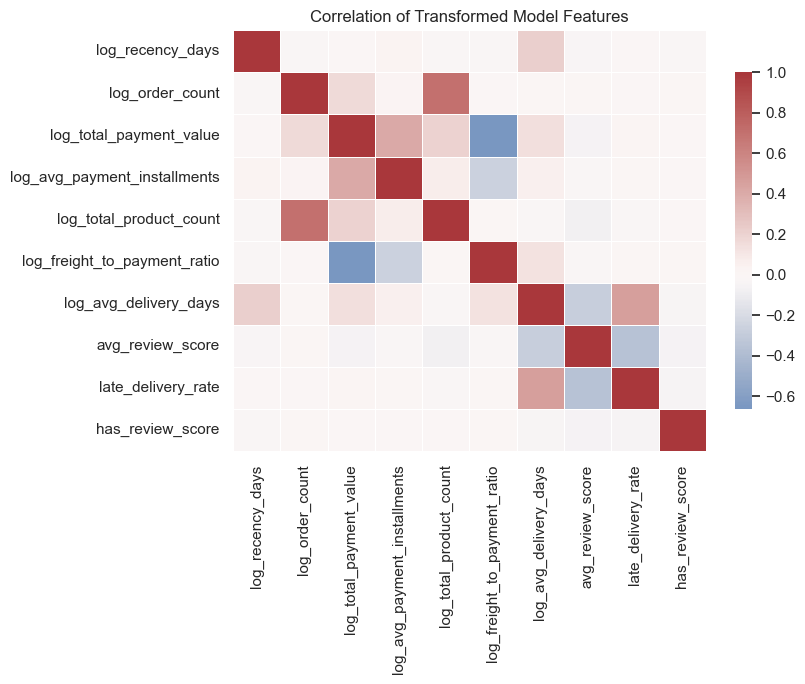

In [14]:
correlation_matrix = transformed_features[model_feature_columns].corr()

plt.figure(figsize=(8.5, 7))
sns.heatmap(
    correlation_matrix,
    cmap="vlag",
    center=0,
    linewidths=0.4,
    cbar_kws={"shrink": 0.8},
)
plt.title("Correlation of Transformed Model Features")
plt.tight_layout()
plt.savefig(figures_dir / "model_feature_correlation_heatmap.png", **FIGURE_SAVE_KWARGS)
plt.show()

In [15]:
upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

high_correlations = (
    upper_triangle.stack()
    .rename("correlation")
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2"})
    .assign(abs_correlation=lambda df: df["correlation"].abs())
    .sort_values("abs_correlation", ascending=False)
    .reset_index(drop=True)
)

display(high_correlations.head(10))

,feature_1,feature_2,correlation,abs_correlation
0,log_order_count,log_total_product_count,0.7016,0.7016
1,log_total_payment_value,log_freight_to_payment_ratio,-0.6622,0.6622
2,log_avg_delivery_days,late_delivery_rate,0.4628,0.4628
3,log_total_payment_value,log_avg_payment_installments,0.4087,0.4087
4,avg_review_score,late_delivery_rate,-0.3604,0.3604
5,log_avg_delivery_days,avg_review_score,-0.2805,0.2805
6,log_avg_payment_installments,log_freight_to_payment_ratio,-0.2649,0.2649
7,log_recency_days,log_avg_delivery_days,0.2212,0.2212
8,log_total_payment_value,log_total_product_count,0.2048,0.2048
9,log_order_count,log_total_payment_value,0.1642,0.1642


## Feature Scaling

K-Means uses distance. Features with larger numerical scales can dominate the distance calculation. Standard scaling makes each feature have approximately zero mean and unit variance.

In [16]:
scaler = StandardScaler()

model_ready_features = transformed_features[["customer_unique_id"]].copy()
model_ready_features[model_feature_columns] = scaler.fit_transform(
    transformed_features[model_feature_columns]
)

print("Model-ready shape:", model_ready_features.shape)
print("Missing values in model-ready features:", model_ready_features.isna().sum().sum())
display(model_ready_features.head())

Model-ready shape: (93350, 11)
Missing values in model-ready features: 0


,customer_unique_id,log_recency_days,log_order_count,log_total_payment_value,log_avg_payment_installments,log_total_product_count,log_freight_to_payment_ratio,log_avg_delivery_days,avg_review_score,late_delivery_rate,has_review_score
0,0000366f3b9a7992bf8c76cfdf3221e2,-0.4790,-0.1702,0.2883,1.7903,-0.2408,-1.0368,-0.6991,0.6581,-0.2995,0.0806
1,0000b849f77a49e4a4ce2b2a4ca5be3f,-0.4508,-0.1702,-1.7193,-0.8543,-0.2408,0.8280,-1.6093,-0.1245,-0.2995,0.0806
2,0000f46a3911fa3c0805444483337064,1.2083,-0.1702,-0.3224,1.7903,-0.2408,-0.0193,1.4326,-0.9071,-0.2995,0.0806
3,0000f6ccb0745a6a4b88665a16c9f078,0.6543,-0.1702,-1.1514,0.7568,-0.2408,1.5674,1.0345,-0.1245,-0.2995,0.0806
4,0004aac84e0df4da2b147fca70cf8255,0.5378,-0.1702,0.6909,1.3484,-0.2408,-1.0254,0.3745,0.6581,-0.2995,0.0806


In [17]:
scaling_summary = (
    model_ready_features[model_feature_columns]
    .agg(["mean", "std"])
    .T
    .reset_index()
    .rename(columns={"index": "feature"})
)

display(scaling_summary)

,feature,mean,std
0,log_recency_days,0.0000,1.0000
1,log_order_count,0.0000,1.0000
2,log_total_payment_value,-0.0000,1.0000
3,log_avg_payment_installments,-0.0000,1.0000
4,log_total_product_count,0.0000,1.0000
5,log_freight_to_payment_ratio,-0.0000,1.0000
6,log_avg_delivery_days,-0.0000,1.0000
7,avg_review_score,-0.0000,1.0000
8,late_delivery_rate,0.0000,1.0000
9,has_review_score,0.0000,1.0000


## Save Preprocessed Outputs

Two local files are saved:

- `customer_features_preprocessed.csv`: transformed features before scaling.
- `customer_features_model_ready.csv`: scaled feature matrix for K-Means.

Both files are ignored by Git because they are reproducible processed data.

In [18]:
preprocessed_output_path = processed_data_dir / "customer_features_preprocessed.csv"
model_ready_output_path = processed_data_dir / "customer_features_model_ready.csv"

transformed_features.to_csv(preprocessed_output_path, index=False)
model_ready_features.to_csv(model_ready_output_path, index=False)

print("Saved preprocessed features to:", relative_project_path(preprocessed_output_path))
print("Saved model-ready features to:", relative_project_path(model_ready_output_path))

Saved preprocessed features to: data/processed/customer_features_preprocessed.csv
Saved model-ready features to: data/processed/customer_features_model_ready.csv


## Feature Validation and Preprocessing Summary

This notebook prepared the customer-level feature table for K-Means clustering.

Important decisions:

- The final row level remains `customer_unique_id`.
- Selected features represent recency, frequency, monetary value, payment behavior, product variety, freight behavior, satisfaction, and delivery experience.
- Missing review scores were handled with median imputation while preserving review availability through `has_review_score`.
- Skewed non-negative features were transformed using `np.log1p`.
- Features were scaled with `StandardScaler` because K-Means is distance-based.
- K-Means is not trained in this notebook.

The next notebook will compare K values using inertia, silhouette score, Davies-Bouldin score, cluster balance, and business interpretability.